---
#### Autoencoder for Reconstruction and Anomaly Detection
---
This notebook demonstrates how to use PyTorch to build and train an autoencoder for data reconstruction and anomaly detection.

**Outline:**
1. Import required libraries (PyTorch, NumPy, etc.)
2. Load and preprocess a dataset (e.g., MNIST or tabular data)
3. Define the autoencoder architecture
4. Train the autoencoder
5. Visualize reconstruction results
6. Detect anomalies using reconstruction error

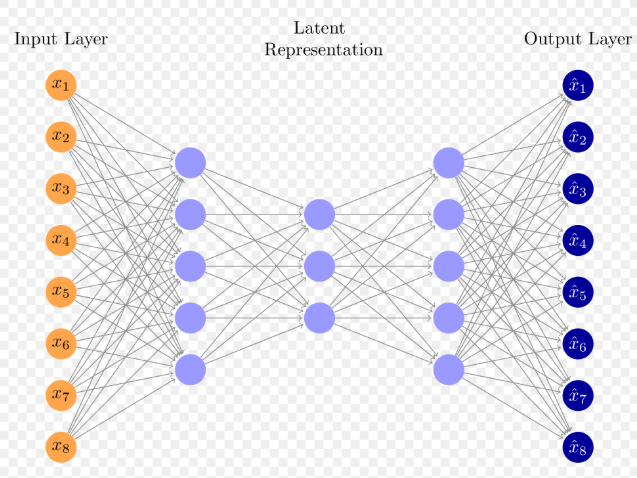

#### Objective: Autoencoder Reconstruction

The primary objective of an autoencoder is **reconstruction**: learning to compress input data into a lower-dimensional representation (encoding) and then accurately reconstruct the original data from this compressed form (decoding).

- **Encoder:** Maps input data (e.g., an image or vector) to a latent (hidden) representation.
- **Decoder:** Reconstructs the input from the latent representation.
- **Training Goal:** Minimize the difference between the input and its reconstruction (e.g., using mean squared error).

#### Why is this "Generative"?
Autoencoders are a foundational generative AI technique because they learn to model the underlying structure of the data. The decoder acts as a **generator**: given a latent code, it produces data that resembles the original distribution.

- In **vanilla autoencoders**, the focus is on faithful reconstruction, not on generating new, diverse samples.
- In **variational autoencoders (VAEs)** and other generative models, the latent space is structured so that sampling from it produces realistic, novel data.

**In summary:**
- Autoencoder reconstruction is the first step toward generative modeling: it teaches the model to "understand" and recreate the data, which is essential for generating new examples, denoising, or anomaly detection.

In [ ]:
# Import required libraries
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [ ]:
# Load and preprocess the MNIST dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    # Normalize to [0,1]
])

In [ ]:
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=128, shuffle=False)


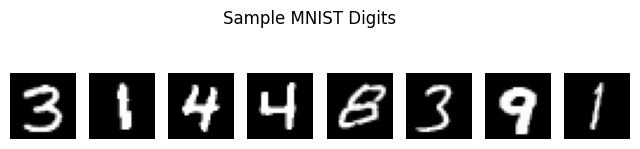

In [6]:
# Visualize a few MNIST images
examples = enumerate(train_loader)
batch_idx, (example_data, example_targets) = next(examples)

plt.figure(figsize=(8,2))
for i in range(8):
    plt.subplot(1,8,i+1)
    plt.imshow(example_data[i][0], cmap='gray')
    plt.axis('off')
plt.suptitle('Sample MNIST Digits')
plt.show()

In [7]:
# Define a simple fully-connected autoencoder for MNIST
class Autoencoder(nn.Module):
    def __init__(self, latent_dim=32):
        super().__init__()
        # Encoder
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dim),
            nn.ReLU()
        )
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 28*28),
            nn.Sigmoid(),  # Output in [0,1]
            nn.Unflatten(1, (1, 28, 28))
        )
    def forward(self, x):
        z = self.encoder(x)
        out = self.decoder(z)
        return out

# Instantiate the model
model = Autoencoder(latent_dim=32)
print(model)

Autoencoder(
  (encoder): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=32, bias=True)
    (4): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=32, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=784, bias=True)
    (3): Sigmoid()
    (4): Unflatten(dim=1, unflattened_size=(1, 28, 28))
  )
)


In [10]:
# Training loop for the autoencoder

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model  = model.to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 10

for epoch in range(1, num_epochs+1):
    model.train()
    running_loss = 0.0
    for imgs, _ in train_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        loss = criterion(outputs, imgs)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)
    avg_loss = running_loss / len(train_loader.dataset)
    print(f"Epoch {epoch}/{num_epochs} - Loss: {avg_loss:.6f}")

Epoch 1/10 - Loss: 0.012584
Epoch 2/10 - Loss: 0.012292
Epoch 3/10 - Loss: 0.012055
Epoch 4/10 - Loss: 0.011841
Epoch 5/10 - Loss: 0.011649
Epoch 6/10 - Loss: 0.011483
Epoch 7/10 - Loss: 0.011331
Epoch 8/10 - Loss: 0.011193
Epoch 9/10 - Loss: 0.011068
Epoch 10/10 - Loss: 0.010964


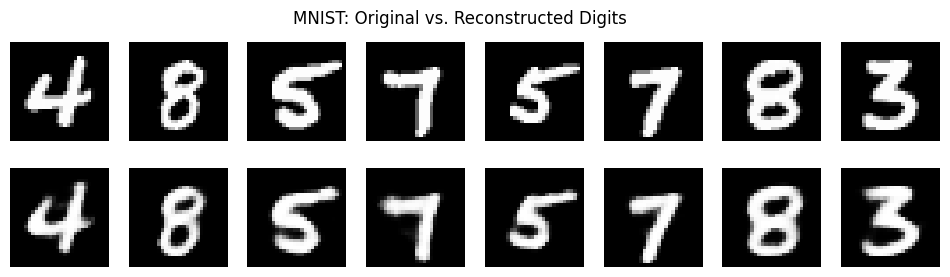

In [23]:
# Visualize original and reconstructed images
import random
model.eval()
with torch.no_grad():
    rand_index = random.randint(0, len(test_loader)-1)
    for i, (imgs, _) in enumerate(test_loader):
        if i == rand_index:
            imgs = imgs.to(device)
            recon = model(imgs)
            break

imgs = imgs.cpu().numpy()
recon = recon.cpu().numpy()

plt.figure(figsize=(12,3))
for i in range(8):
    # Original
    plt.subplot(2,8,i+1)
    plt.imshow(imgs[i][0], cmap='gray')
    plt.axis('off')
    if i == 0:
        plt.ylabel('Original')
    # Reconstructed
    plt.subplot(2,8,i+9)
    plt.imshow(recon[i][0], cmap='gray')
    plt.axis('off')
    if i == 0:
        plt.ylabel('Reconstructed')
plt.suptitle('MNIST: Original vs. Reconstructed Digits')
plt.show()

#### How is the Autoencoder "Generating"?

The decoder part of the autoencoder is a **generator**: it takes a latent code (the compressed representation) and produces an output image. During normal use, the latent code comes from the encoder, which compresses a real image. But you can also feed any vector (even random noise) into the decoder, and it will generate an image-like output.

- **Reconstruction:** The model generates an image that closely matches the input, showing it has learned the data's structure.
- **Latent Space Traversal:** By manipulating the latent code, you can generate new images that are similar to the training data.
- **Generative Principle:** The decoder learns to map points in the latent space to realistic images, making it a generative model, even if its main goal is reconstruction.

In more advanced models (like VAEs), the latent space is explicitly structured for sampling and generation, but even a basic autoencoder's decoder is a simple generator.

### Part II: Visualizing the Latent Space (2D)

Now, let's set the latent dimension to 2 and visualize the encoded MNIST test set in the 2D latent space, colored by digit label. This helps us see how well the autoencoder separates different digits in its compressed representation.

In [24]:
# Set up a new autoencoder with latent_dim=2 for visualization
latent_dim = 2
model_2d   = Autoencoder(latent_dim=latent_dim).to(device)

In [14]:
# (Re)train the model for a few epochs (for demo, fewer epochs)
optimizer_2d = optim.Adam(model_2d.parameters(), lr=1e-3)
num_epochs   = 5

for epoch in range(1, num_epochs+1):
    model_2d.train()
    running_loss = 0.0
    for imgs, _ in train_loader:
        imgs    = imgs.to(device)
        outputs = model_2d(imgs)
        loss    = criterion(outputs, imgs)
        
        optimizer_2d.zero_grad()
        loss.backward()
        optimizer_2d.step()
        running_loss += loss.item() * imgs.size(0)
    avg_loss = running_loss / len(train_loader.dataset)
    print(f"[2D] Epoch {epoch}/{num_epochs} - Loss: {avg_loss:.6f}")

# Collect latent codes for the test set
model_2d.eval()
latents = []
labels  = []
with torch.no_grad():
    for imgs, lbls in test_loader:
        imgs = imgs.to(device)
        z    = model_2d.encoder(imgs)
        latents.append(z.cpu().numpy())
        labels.append(lbls.numpy())
        
latents = np.concatenate(latents, axis=0)
labels  = np.concatenate(labels,  axis=0)

[2D] Epoch 1/5 - Loss: 0.066433
[2D] Epoch 2/5 - Loss: 0.053360
[2D] Epoch 3/5 - Loss: 0.051440
[2D] Epoch 4/5 - Loss: 0.050032
[2D] Epoch 5/5 - Loss: 0.048833


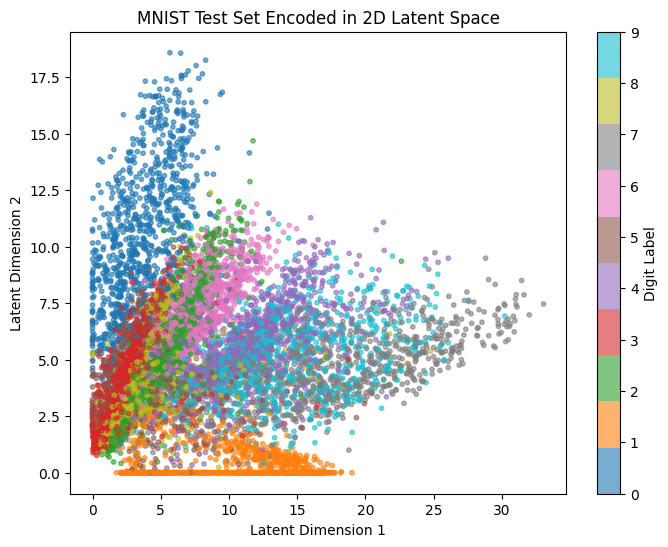

In [15]:
# Plot the 2D latent space
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
scatter = plt.scatter(latents[:,0], latents[:,1], c=labels, cmap='tab10', alpha=0.6, s=10)
cbar = plt.colorbar(scatter, ticks=range(10))
cbar.set_label('Digit Label')
plt.xlabel('Latent Dimension 1')
plt.ylabel('Latent Dimension 2')
plt.title('MNIST Test Set Encoded in 2D Latent Space')
plt.show()

#### Intuitive Explanation: Latent Space for MNIST

The **latent space** is the compressed, abstract representation that the autoencoder learns for each input image. For MNIST, each digit image (28x28 pixels) is mapped to a point in a much lower-dimensional space (here, just 2D).

- **What does this mean?**
  - Each point in the 2D latent space represents a digit image.
  - Images of the same digit (e.g., all 3s) tend to cluster together, because their features are similar.
  - Different digits form separate clusters, but sometimes overlap if they look similar (e.g., 4 and 9).

- **Why is this useful?**
  - The latent space captures the essential "concept" of each digit, ignoring irrelevant details.
  - You can visualize how the model "understands" the data: well-separated clusters mean the model has learned meaningful features.
  - By moving around in latent space, you can generate new images that smoothly transition between digits.

**In summary:**
- The latent space is like a map of the digit world, where each location corresponds to a different style or type of digit. The autoencoder learns this map automatically, just by trying to reconstruct the input images.

#### Why Do Random Latent Points Look Strange?

When you encode a real MNIST digit, its latent code lands in a region of latent space that the autoencoder has learned to map to realistic digits. Decoding these points produces good reconstructions.

But if you pick a random point in latent space (especially far from the clusters of real digits), the decoder has never seen such codes during training. As a result:
- The output is often blurry, noisy, or doesn't look like a digit at all.
- The decoder only "knows" how to generate images for the regions of latent space it has seen during training.

**Key idea:**
- The latent space is not filled uniformly with valid digit codes. Only certain regions correspond to real, meaningful digits.
- Random points usually fall outside these regions, so the generated images are not realistic.

This is why more advanced generative models (like VAEs) are designed to "fill" the latent space more smoothly, so that random samples are more likely to produce realistic outputs.